In [11]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy

In [12]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [13]:
# Load best-fit models and data

u = 1.3e-8

graph_Bherer_0 = "models/den_null_Bherer_MLE.yaml"
graph_ZhouJHS_0 = "models/den_null_ZhouJHS_MLE.yaml"
params_0 = "models/den_null_params.yaml"
graph_Bherer_1 = "models/den_contraction_Bherer_MLE.yaml"
graph_ZhouJHS_1 = "models/den_contraction_ZhouJHS_MLE.yaml"
params_1 = "models/den_contraction_params.yaml"

fdata_Bherer = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"
fdata_ZhouJHS = "../../analyses/recombination_maps/stats/subset_ZhouJHS.pkl"

data_Bherer = dpluspy.inference.load_stats(
    fdata_Bherer, graph=graph_Bherer_0, return_dict=True)
data_ZhouJHS = dpluspy.inference.load_stats(
    fdata_ZhouJHS, graph=graph_Bherer_0, return_dict=True)

model_Bherer_0 = dpluspy.inference.compute_bin_stats(graph_Bherer_0, 
    sampled_demes=data_Bherer["pop_ids"], bins=data_Bherer["bins"], u=u)
model_ZhouJHS_0 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_0, 
    sampled_demes=data_ZhouJHS["pop_ids"], bins=data_ZhouJHS["bins"], u=u)

model_Bherer_1 = dpluspy.inference.compute_bin_stats(graph_Bherer_1, 
    sampled_demes=data_Bherer["pop_ids"], bins=data_Bherer["bins"], u=u)
model_ZhouJHS_1 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_1, 
    sampled_demes=data_ZhouJHS["pop_ids"], bins=data_ZhouJHS["bins"], u=u)

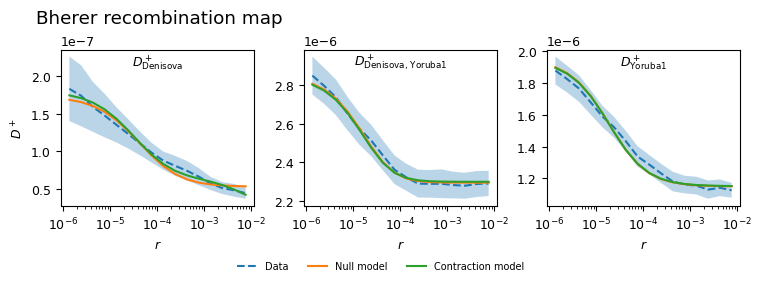

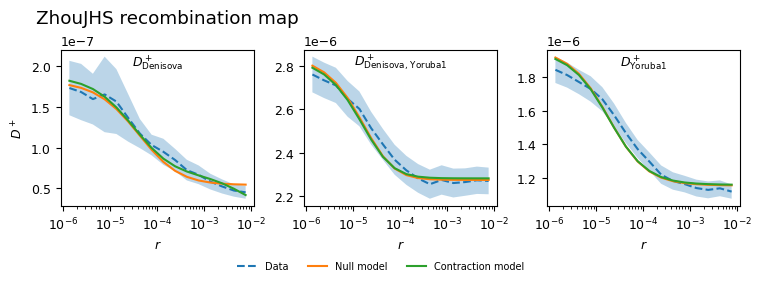

In [14]:
# Plot best-fit models

dpluspy.plotting.plot_D_plus_curves(
    models=[model_Bherer_0, model_Bherer_1],
    pop_ids=data_Bherer["pop_ids"], 
    bins=data_Bherer["bins"], 
    means=data_Bherer["means"], 
    varcovs=data_Bherer["varcovs"], 
    labels=["Data", "Null model", "Contraction model"],
    title="Bherer recombination map",
    ax_size=2.5,
    out="figures/Bherer_MLE_models.pdf"
)

dpluspy.plotting.plot_D_plus_curves(
    models=[model_ZhouJHS_0, model_ZhouJHS_1],
    pop_ids=data_ZhouJHS["pop_ids"], 
    bins=data_ZhouJHS["bins"], 
    means=data_ZhouJHS["means"], 
    varcovs=data_ZhouJHS["varcovs"], 
    labels=["Data", "Null model", "Contraction model"],
    title="ZhouJHS recombination map",
    ax_size=2.5,
    out="figures/ZhouJHS_MLE_models.pdf"
)

In [15]:
# Load and aggregate bootstrap-replicate fits

model_0 = "null"
model_1 = "contraction"
datasets = ["Bherer", "ZhouJHS"]
num_reps = 100

for dataset in datasets:
    results_0 = []
    results_1 = []
    for rep in range(num_reps):
        fname_0 = f"bootstrap_fits/den_{model_0}_{dataset}_rep{rep}.csv"
        fname_1 = f"bootstrap_fits/den_{model_1}_{dataset}_rep{rep}.csv"
        try:
            result_0 = pandas.read_csv(fname_0)
            result_1 = pandas.read_csv(fname_1)
            results_0.append(result_0)
            results_1.append(result_1)
        except:
            print(f"Missing file {fname_0} or {fname_1}")
    out_fname_0 = f"{model_0}_{dataset}_bootstrap.csv"
    out_fname_1 = f"{model_1}_{dataset}_bootstrap.csv"
    pandas.concat(results_0).to_csv(out_fname_0, index=False)
    pandas.concat(results_1).to_csv(out_fname_1, index=False)

null_Bherer_fits = pandas.read_csv("null_Bherer_bootstrap.csv")
alt_Bherer_fits = pandas.read_csv("contraction_Bherer_bootstrap.csv")
null_ZhouJHS_fits = pandas.read_csv("null_ZhouJHS_bootstrap.csv")
alt_ZhouJHS_fits = pandas.read_csv("contraction_ZhouJHS_bootstrap.csv")

ll0_B = np.array(null_Bherer_fits["ll"])
ll1_B = np.array(alt_Bherer_fits["ll"])
ll0_Z = np.array(null_ZhouJHS_fits["ll"])
ll1_Z = np.array(alt_ZhouJHS_fits["ll"])

In [16]:
# Find the naive alpha = 0.05 rejection threshold

weights = (0, 0.5, 0.5)
thresh = 5.139
print(moments.Godambe.sum_chi2_ppf(thresh, weights))

0.04998397131113563


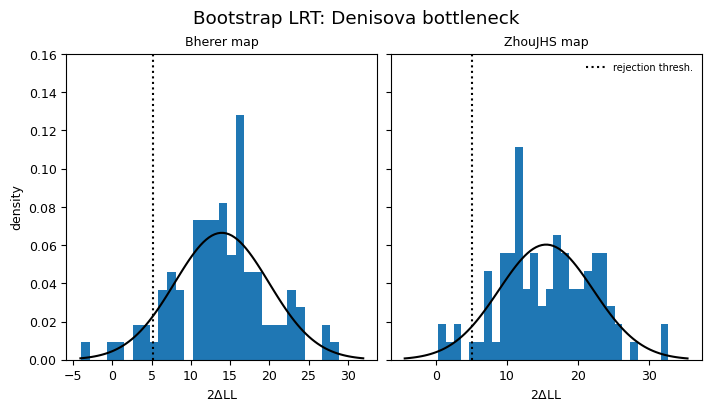

In [17]:
# Plot D (2 Delta LL) distributions

D_B = 2 * (ll1_B - ll0_B)
D_Z = 2 * (ll1_Z - ll0_Z)

mean_D_B = np.mean(D_B)
std_D_B = np.std(D_B)
x0 = np.linspace(mean_D_B - std_D_B * 3, mean_D_B + std_D_B * 3, 100)
y0 = scipy.stats.norm.pdf(x0, mean_D_B, std_D_B)

mean_D_Z = np.mean(D_Z)
std_D_Z = np.std(D_Z)
x1 = np.linspace(mean_D_Z - std_D_Z * 3, mean_D_Z + std_D_Z * 3, 100)
y1 = scipy.stats.norm.pdf(x1, mean_D_Z, std_D_Z)

fig, (ax0, ax1) = plt.subplots(
    1, 2, figsize=(7, 4), sharey=True, layout="constrained")

fig.suptitle("Bootstrap LRT: Denisova bottleneck")


ax0.set_ylim(0, 0.16)
ax0.hist(D_B, bins=30, color="tab:blue", density=True)
ax0.plot(x0, y0, color="black")
ax0.vlines(thresh, 0, 1, transform=ax0.get_xaxis_transform(),
    color="black", linestyles="dotted", label="rejection thresh.")
ax0.set_title("Bherer map")
ax0.set_xlabel(r"$2\Delta \text{LL}$")
ax0.set_ylabel("density")
# ax0.legend(framealpha=0)

ax1.hist(D_Z, bins=30, color="tab:blue", density=True)
ax1.plot(x1, y1, color="black")
ax1.vlines(thresh, 0, 1, transform=ax1.get_xaxis_transform(),
    color="black", linestyles="dotted", label="rejection thresh.")
ax1.set_title("ZhouJHS map")
ax1.set_xlabel(r"$2\Delta \text{LL}$")
ax1.legend(framealpha=0)

plt.savefig("figures/bootstrap_LRT_distributions.pdf")

In [18]:
# Compute bootstrap LRT test significance

boot_sig_B = np.count_nonzero(D_B < thresh) / len(D_B)
Zscore_B = (mean_D_B - thresh) / std_D_B
Zscore_sig_B = scipy.stats.norm.sf(Zscore_B)

print(boot_sig_B, Zscore_B, Zscore_sig_B)

boot_sig_Z = np.count_nonzero(D_Z < thresh) / len(D_Z)
Zscore_Z = (mean_D_Z - thresh) / std_D_Z
Zscore_sig_Z = scipy.stats.norm.sf(Zscore_Z)

print(boot_sig_Z, Zscore_Z, Zscore_sig_Z)

0.07 1.4669452954767614 0.0711954686606669
0.05 1.5655090687649942 0.05873179632969712
